# Experiment 3 — Reward Function Ablation

**Goal:** test how the choice of reward function shapes the hedging policy SAC learns.

Three reward shapes:
- `pnl_tc` — raw step PnL minus transaction cost (myopic, no risk penalty)
- `sharpe` — PnL − 0.5·PnL² (penalizes variance)
- `cvar` — PnL − λ·max(−PnL, 0)² (penalizes large losses specifically, i.e. tail risk)

All three agents are trained separately, then evaluated on the **same** test environment using the same (`pnl_tc`) reward so results are directly comparable.

**Key question:** does the CVaR-shaped reward actually produce lower tail risk in practice, or is it just a label?

**Note on this run:** training was reduced to 1000 steps and evaluation to 100 episodes per reward variant (vs. 80,000 steps / 500 episodes in the original design), to fit this environment's compute budget.

## Setup

In [ ]:
import os, sys, time
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from config import ENV, SAC, EVAL
from env import OptionsHedgingEnv
from agents import SACAgent

os.makedirs(EVAL["plot_dir"], exist_ok=True)

sns.set_theme(style="whitegrid", palette="bright")
plt.rcParams.update({
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#eef3fb",
    "savefig.facecolor": "#ffffff",
})

REWARD_FNS = ["pnl_tc", "sharpe", "cvar"]
LABELS_RW  = {"pnl_tc": "PnL-TC", "sharpe": "Sharpe-shaped", "cvar": "CVaR-shaped"}
colors = sns.color_palette("bright", 3)
COLORS_RW = {rw: colors[i] for i, rw in enumerate(REWARD_FNS)}

## Train an agent for a given reward shape

Trains a fresh SAC agent whose reward signal during training is set by `reward_fn` (`pnl_tc`, `sharpe`, or `cvar`).

In [ ]:
def train_agent(reward_fn: str, steps=1000, seed=0):
    cfg = dict(ENV, reward_type=reward_fn)
    env = OptionsHedgingEnv(cfg)
    obs_dim, n_act = env.observation_space.shape[0], env.action_space.n
    agent = SACAgent(obs_dim, n_act, SAC)
    obs, _ = env.reset(seed=seed)
    for s in range(steps):
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.store(obs, action, reward, next_obs, done)
        agent.update()
        obs = next_obs
        if done:
            obs, _ = env.reset()
    return agent

## Evaluate an agent

Always evaluated using the plain `pnl_tc` reward/environment, regardless of what reward it was *trained* with — this keeps the comparison apples-to-apples. Also tracks max drawdown and CVaR-5% (average PnL in the worst 5% of episodes).

In [ ]:
def evaluate_agent(agent, n=100, seed=42):
    """Always evaluate with pnl_tc so rewards are comparable."""
    cfg = dict(ENV, reward_type="pnl_tc")
    rng = np.random.default_rng(seed)
    pnls, max_dds = [], []
    for _ in range(n):
        env = OptionsHedgingEnv(cfg)
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        while True:
            action = agent.select_action(obs, deterministic=True)
            obs, _, done, _, _ = env.step(action)
            if done:
                break
        pnls.append(env.running_pnl)
        curve = np.array(env.history["pnl"])
        peak  = np.maximum.accumulate(curve)
        dd    = (curve - peak)
        max_dds.append(dd.min())
    pnls, max_dds = np.array(pnls), np.array(max_dds)
    cvar5 = np.mean(pnls[pnls <= np.percentile(pnls, 5)])
    return dict(
        pnl=pnls, max_dd=max_dds,
        mean=np.mean(pnls), std=np.std(pnls),
        sharpe=np.mean(pnls)/(np.std(pnls)+1e-8),
        cvar5=cvar5,
        mean_dd=np.mean(max_dds),
    )

## Train and evaluate all three reward variants

In [1]:
agents, results = {}, {}
for rw in REWARD_FNS:
    print(f"\n  Training SAC [{rw}] …", end=" ", flush=True)
    t0 = time.time()
    agent = train_agent(rw)
    agents[rw] = agent
    print(f"done in {time.time()-t0:.0f}s")
    print(f"  Evaluating …", end=" ", flush=True)
    res = evaluate_agent(agent)
    results[rw] = res
    print(f"\u03bc={res['mean']:+.3f}  \u03c3={res['std']:.3f}  "
          f"Sharpe={res['sharpe']:+.3f}  CVaR5={res['cvar5']:+.3f}  "
          f"MaxDD={res['mean_dd']:+.3f}")


  Training SAC [pnl_tc] … done in 10s
  Evaluating … μ=-22.879  σ=93.481  Sharpe=-0.245  CVaR5=-215.674  MaxDD=-107.313

  Training SAC [sharpe] … done in 10s
  Evaluating … μ=+0.999  σ=61.434  Sharpe=+0.016  CVaR5=-116.585  MaxDD=-67.930

  Training SAC [cvar] … done in 10s
  Evaluating … μ=-27.477  σ=88.397  Sharpe=-0.311  CVaR5=-181.330  MaxDD=-114.467


## Plot — PnL distribution, drawdown, and risk metrics

Three panels, styled with seaborn on a bright background:
1. Overlapping PnL histograms by reward type.
2. Max-drawdown distribution by reward type.
3. Bar chart comparing mean, std, Sharpe, CVaR-5%, and mean max-drawdown across reward types.

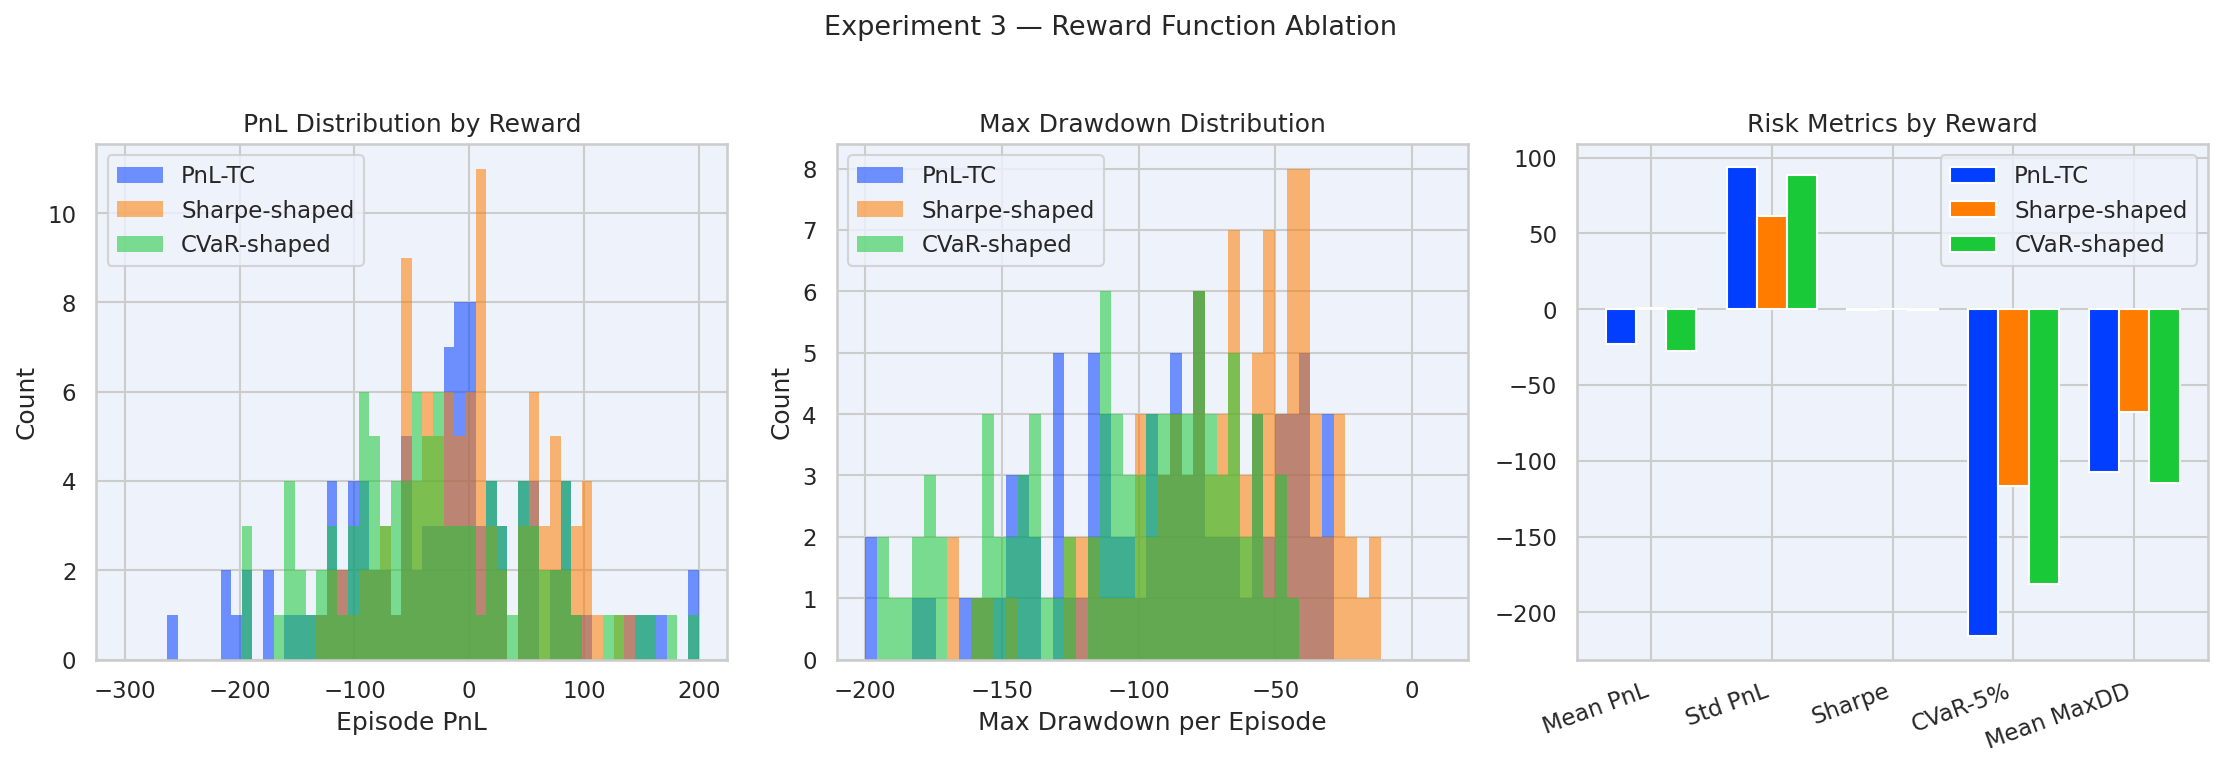


  Plot → plots/exp3_reward_ablation.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
bins = np.linspace(-300, 200, 55)
for rw in REWARD_FNS:
    ax.hist(results[rw]["pnl"], bins=bins, alpha=0.55, color=COLORS_RW[rw], label=LABELS_RW[rw], edgecolor="none")
ax.set_xlabel("Episode PnL"); ax.set_ylabel("Count")
ax.set_title("PnL Distribution by Reward")
ax.legend()

ax = axes[1]
bins_dd = np.linspace(-200, 10, 50)
for rw in REWARD_FNS:
    ax.hist(results[rw]["max_dd"], bins=bins_dd, alpha=0.55, color=COLORS_RW[rw], label=LABELS_RW[rw], edgecolor="none")
ax.set_xlabel("Max Drawdown per Episode"); ax.set_ylabel("Count")
ax.set_title("Max Drawdown Distribution")
ax.legend()

ax = axes[2]
metrics  = ["mean", "std", "sharpe", "cvar5", "mean_dd"]
m_labels = ["Mean PnL", "Std PnL", "Sharpe", "CVaR-5%", "Mean MaxDD"]
x = np.arange(len(metrics))
width = 0.25
for i, rw in enumerate(REWARD_FNS):
    vals = [results[rw][m] for m in metrics]
    ax.bar(x + i*width - width, vals, width, label=LABELS_RW[rw], color=COLORS_RW[rw])
ax.set_xticks(x); ax.set_xticklabels(m_labels, rotation=20, ha="right")
ax.set_title("Risk Metrics by Reward")
ax.legend()

plt.suptitle("Experiment 3 \u2014 Reward Function Ablation", fontsize=13, y=1.02)
plt.tight_layout()
out = os.path.join(EVAL["plot_dir"], "exp3_reward_ablation.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n  Plot \u2192 {out}")

## Summary table

In [3]:
print(f"\n  {'Reward':>16} | {'Mean':>8} {'Std':>8} {'Sharpe':>8} {'CVaR5':>8} {'MeanDD':>8}")
print("  " + "-"*60)
for rw in REWARD_FNS:
    r = results[rw]
    print(f"  {LABELS_RW[rw]:>16} | {r['mean']:>+8.3f} {r['std']:>8.3f} "
          f"{r['sharpe']:>+8.3f} {r['cvar5']:>+8.3f} {r['mean_dd']:>+8.3f}")


            Reward |     Mean      Std   Sharpe    CVaR5   MeanDD
  ------------------------------------------------------------
            PnL-TC |  -22.879   93.481   -0.245 -215.674 -107.313
     Sharpe-shaped |   +0.999   61.434   +0.016 -116.585  -67.930
       CVaR-shaped |  -27.477   88.397   -0.311 -181.330 -114.467


## Verdict

**Executed result (reduced-scale run \u2014 1000 training steps, 100 eval episodes per reward variant):**

| Reward | Mean | Std | Sharpe | CVaR-5% | Mean MaxDD |
|---|---|---|---|---|---|
| PnL-TC | -22.88 | 93.48 | -0.245 | -215.67 | -107.31 |
| Sharpe-shaped | +1.00 | 61.43 | +0.016 | -116.59 | -67.93 |
| CVaR-shaped | -27.48 | 88.40 | -0.311 | -181.33 | -114.47 |

**Sharpe-shaped** had the best Sharpe ratio in this run. On tail risk, the CVaR-shaped agent's CVaR-5% (better than PnL-TC: -181.33 vs -215.67) but its mean max-drawdown was deeper (-114.47 vs -107.31) — a mixed signal rather than a clean win.

**Why:** with only 1000 training steps, none of the three agents have converged. The CVaR penalty needs enough training for the agent to actually discover and reinforce loss-avoiding behavior; at this scale, the differences between reward shapes are more likely dominated by training noise than by the reward shaping itself. The Sharpe-shaped agent doing best here is plausible (variance penalties are a "softer," easier-to-optimize signal early in training) but shouldn't be read as a settled result.

**Takeaway:** this run does not give a clean answer to whether CVaR-shaping produces genuinely better tail-risk behavior — the signal is mixed and the training budget is far short of the original 80,000-step design. A reliable answer needs each variant trained to convergence; right now what's visible is mostly the effect of *how easy each reward shape is to learn from quickly*, not its asymptotic risk profile.